In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score,mean_absolute_percentage_error
import pandas as pd
import matplotlib.pyplot as plt
import jeet

In [3]:
df = pd.read_csv("Verrucodesmus_verrucosus.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Irradiance    1080 non-null   float64
 1   NO3           1080 non-null   float64
 2   Temperature   1080 non-null   float64
 3   pH            1080 non-null   float64
 4   Biomass       1080 non-null   float64
 5   O2 Gas        1080 non-null   float64
 6   CO2 Gas       1080 non-null   float64
 7   OD            1080 non-null   float64
 8   Conductivity  1080 non-null   float64
dtypes: float64(9)
memory usage: 76.1 KB


In [5]:
df.drop(columns=['OD'],inplace = True)

In [6]:
y = df['Biomass']
x = df.drop(columns=['Biomass'])

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

In [8]:
forest_model = RandomForestRegressor()

In [9]:
forest_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_predict = forest_model.predict(x_test)

In [11]:
tup = (y_predict,y_test)

In [12]:
r2_score(*tup),mean_absolute_percentage_error(*tup),mean_absolute_error(*tup)

(0.9864472281870472, 0.0580044237215683, 0.06948134259259245)

In [13]:
df_pred = pd.DataFrame(y_predict,y_test)

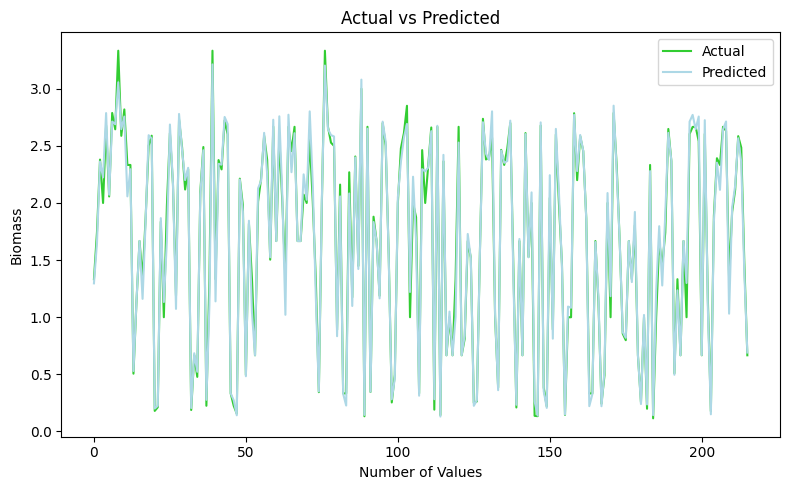

In [14]:
jeet.LinePlotAfterPrediction(y_test,y_predict)

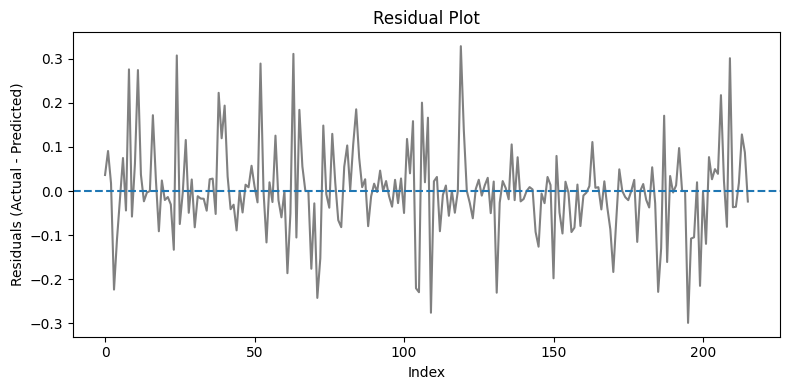

In [15]:
jeet.PredictionPlotResidual(y_test,y_predict)

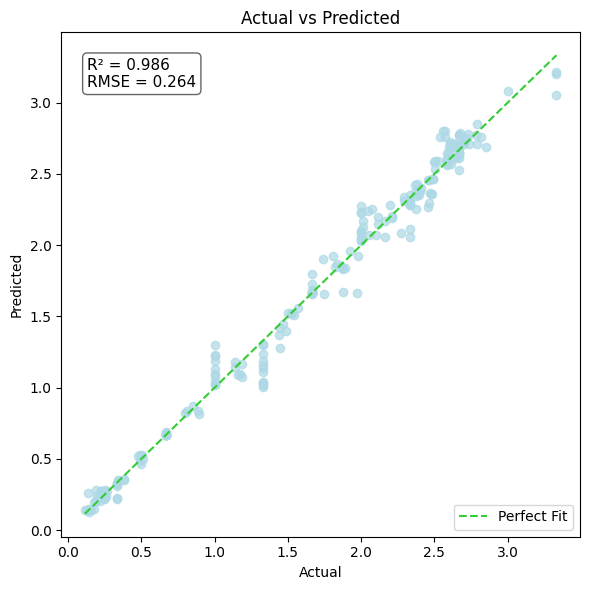

In [16]:
jeet.ScatterPlotAfterPrediction(y_test,y_predict)

In [17]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(forest_model, f)

In [ ]:
# predictions = loaded_model.predict(X_test)

In [18]:
dfcol = df.columns.to_list()

In [32]:
df['Temperature'].describe()

count    1080.000000
mean       22.365758
std         0.949002
min        20.921888
25%        21.498363
50%        22.235716
75%        23.305544
max        23.892744
Name: Temperature, dtype: float64

In [19]:
dfcol

['Irradiance',
 'NO3',
 'Temperature',
 'pH',
 'Biomass',
 'O2 Gas',
 'CO2 Gas',
 'Conductivity']